# Systematic ETF Momentum Strategy

## Final Research Report

This notebook evaluates a simple cross-sectional momentum strategy applied to a multi-asset ETF universe.

The goal is to test whether selecting the strongest ETFs based on trailing momentum can outperform a monthly rebalanced equal-weight benchmark after accounting for portfolio drift, turnover, and transaction costs.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.metrics import (
    compute_returns,
    cumulative_returns,
    drawdown_series,
    performance_summary,
    rolling_volatility,
    rolling_sharpe_ratio,
)

from src.signals import momentum_signal

from src.portfolio import (
    monthly_rebalance_with_drift,
    monthly_top_n_momentum_portfolio_with_costs,
)

## 1. Data

The strategy uses daily adjusted ETF prices for a diversified multi-asset universe.

| ETF | Asset Class |
|---|---|
| SPY | US Equities |
| EFA | Developed Markets Equities |
| EEM | Emerging Markets Equities |
| TLT | Long-Term US Treasuries |
| GLD | Gold |
| VNQ | Real Estate |

Daily returns are computed from adjusted prices.

In [3]:
prices = pd.read_csv(
    "../data/raw/etf_prices.csv",
    index_col=0,
    parse_dates=True,
)

returns = compute_returns(prices)
signals = momentum_signal(prices, lookback=252)

returns.head()

,EEM,EFA,GLD,SPY,TLT,VNQ
Date,,,,,,
2010-01-05,0.007258,0.000881,-0.000911,0.002647,0.006459,-0.001123
2010-01-06,0.002092,0.004227,0.016500,0.000704,-0.013387,-0.001798
2010-01-07,-0.005799,-0.003858,-0.006188,0.004221,0.001681,0.010806
2010-01-08,0.007933,0.007922,0.004963,0.003327,-0.000447,-0.007350
2010-01-11,-0.002084,0.008210,0.013289,0.001397,-0.005489,0.005833


## 2. Methodology

This report compares three portfolio return series:

1. **Monthly Equal Weight Benchmark**
   - Holds all available ETFs equally
   - Rebalanced monthly
   - Weights drift between rebalancing dates

2. **Momentum Strategy — Gross**
   - Computes trailing 12-month momentum
   - Selects the top 3 ETFs at each month-end
   - Holds selected ETFs during the next month
   - Weights drift intra-month

3. **Momentum Strategy — Net**
   - Same as the gross momentum strategy
   - Includes transaction costs based on portfolio turnover

Transaction costs are modeled as:

$$\text{Cost} = \text{Turnover} \times \text{Cost Rate}$$

The assumed cost rate is 10 basis points per unit turnover.

In [4]:
n_assets = returns.shape[1]

target_weights = pd.Series(
    1 / n_assets,
    index=returns.columns,
)

cost_results, weights_history = monthly_top_n_momentum_portfolio_with_costs(
    returns=returns,
    signals=signals,
    n_assets=3,
    cost_rate=0.001,
    return_weights=True,
)

monthly_equal_weight_returns = monthly_rebalance_with_drift(
    returns=returns.loc[cost_results.index],
    target_weights=target_weights,
)

## 3. Performance Summary

The table below compares the monthly equal-weight benchmark with the gross and net momentum strategies.

In [5]:
summary = pd.DataFrame({
    "Monthly Equal Weight": performance_summary(monthly_equal_weight_returns),
    "Momentum Gross": performance_summary(cost_results["gross_return"]),
    "Momentum Net": performance_summary(cost_results["net_return"]),
})

summary

,Monthly Equal Weight,Momentum Gross,Momentum Net
Annualized Return,0.078451,0.094575,0.093213
Annualized Volatility,0.117899,0.129095,0.129087
Sharpe Ratio,0.665404,0.732598,0.722094
Max Drawdown,-0.260502,-0.257972,-0.258278


## 4. Equity Curve Comparison

The equity curve shows cumulative performance over time.

This helps evaluate whether the momentum strategy produced persistent outperformance relative to the benchmark.

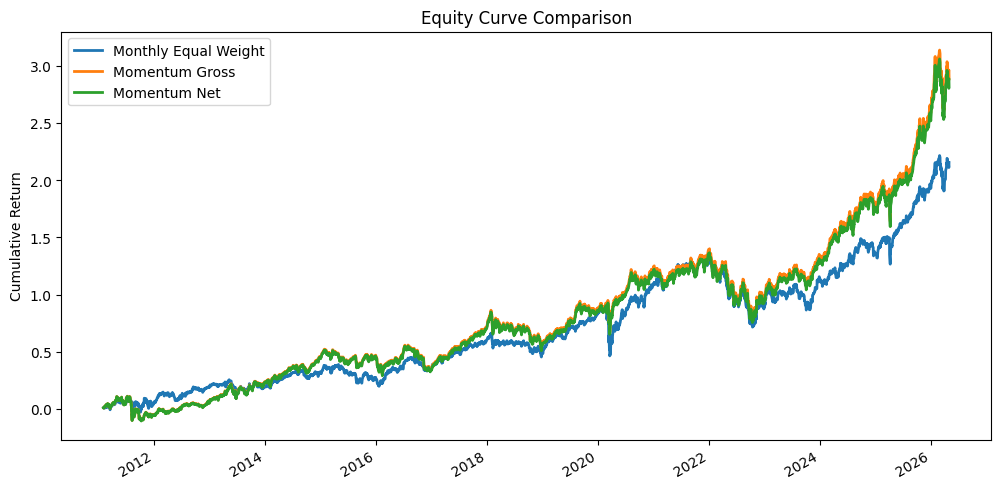

In [8]:
equity_curves = pd.DataFrame({
    "Monthly Equal Weight": cumulative_returns(monthly_equal_weight_returns),
    "Momentum Gross": cumulative_returns(cost_results["gross_return"]),
    "Momentum Net": cumulative_returns(cost_results["net_return"]),
})

equity_curves.plot(
    figsize=(12, 6),
    linewidth=2,
    title="Equity Curve Comparison",
)

plt.ylabel("Cumulative Return")
plt.show()

## 5. Drawdown Analysis

Drawdowns measure losses from previous portfolio peaks.

A value of 0 means the strategy is at a new high. Negative values show how far the strategy is below its previous peak.

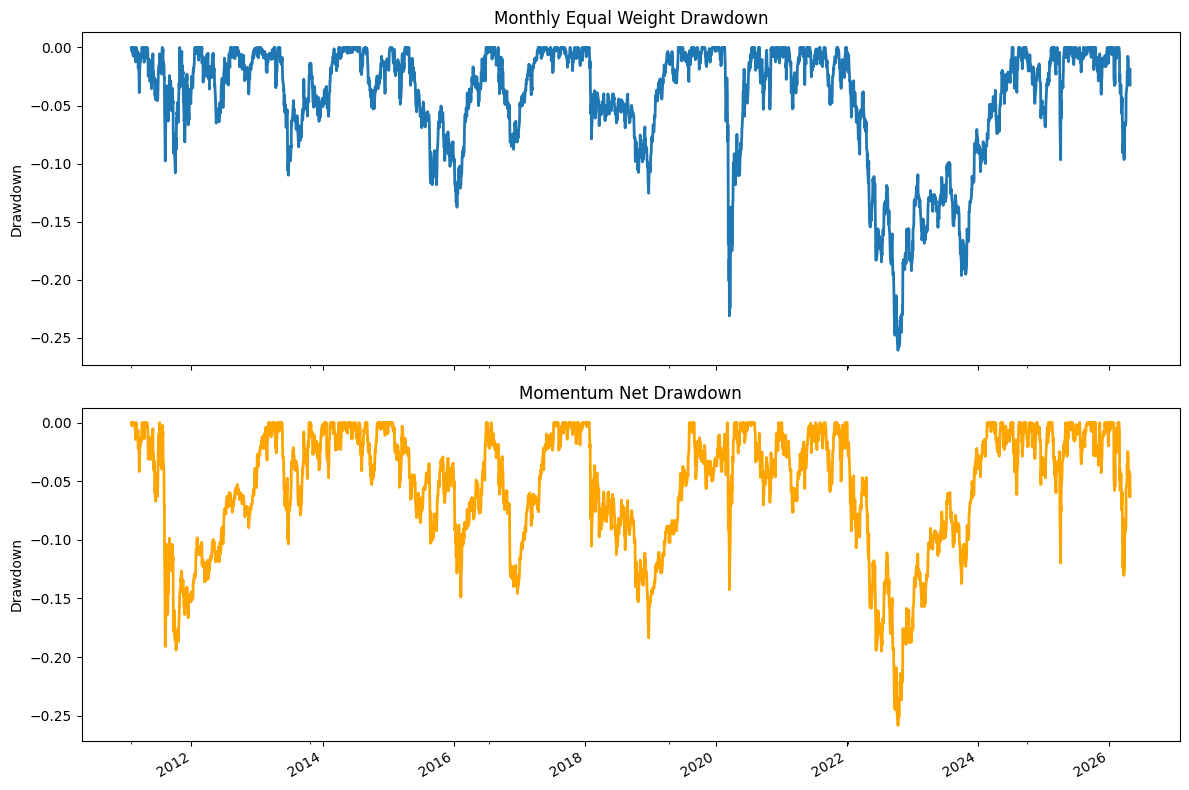

In [11]:
drawdowns = pd.DataFrame({
    "Monthly Equal Weight": drawdown_series(monthly_equal_weight_returns),
    "Momentum Net": drawdown_series(cost_results["net_return"]),
})

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

drawdowns["Monthly Equal Weight"].plot(
    ax=axes[0],
    linewidth=2,
    title="Monthly Equal Weight Drawdown",
)

drawdowns["Momentum Net"].plot(
    ax=axes[1],
    linewidth=2,
    title="Momentum Net Drawdown",
    color="orange"
)

axes[0].set_ylabel("Drawdown")
axes[1].set_ylabel("Drawdown")

plt.tight_layout()
plt.show()

### Interpretation

- Momentum had higher cumulative performance than the monthly equal-weight benchmark.
- Transaction costs had a small impact on final performance. -> depend on assumptions.
- Momentum had similar drawdown behavior than the benchmark. -> only evaluated visually.

## 6. Rolling Risk Analytics

Point-in-time metrics can hide important changes in strategy behavior.

Rolling volatility and rolling Sharpe ratio help evaluate whether the strategy's risk and risk-adjusted performance were stable over time.

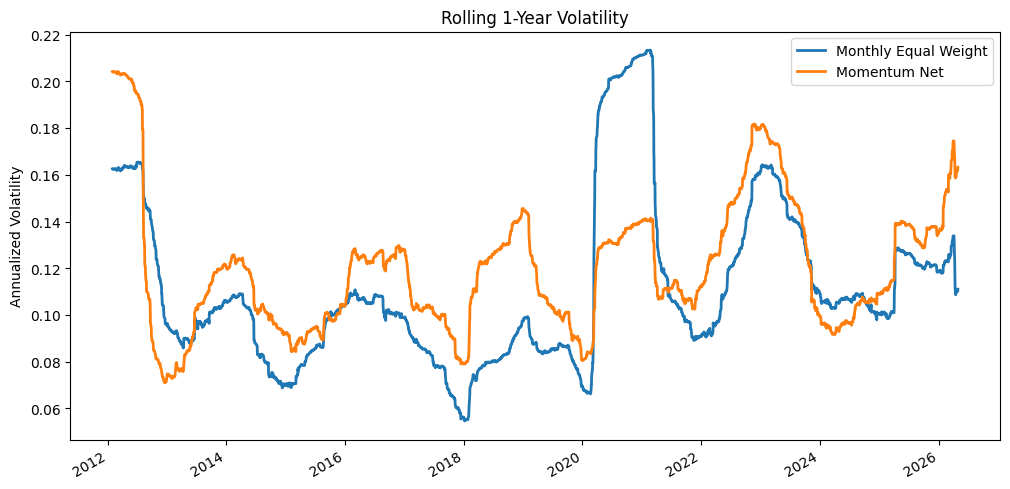

In [12]:
rolling_vol = pd.DataFrame({
    "Monthly Equal Weight":
        monthly_equal_weight_returns.rolling(252).std() * (252 ** 0.5),

    "Momentum Net":
        cost_results["net_return"].rolling(252).std() * (252 ** 0.5),
})

rolling_vol.plot(
    figsize=(12, 6),
    linewidth=2,
    title="Rolling 1-Year Volatility",
)

plt.ylabel("Annualized Volatility")
plt.show()

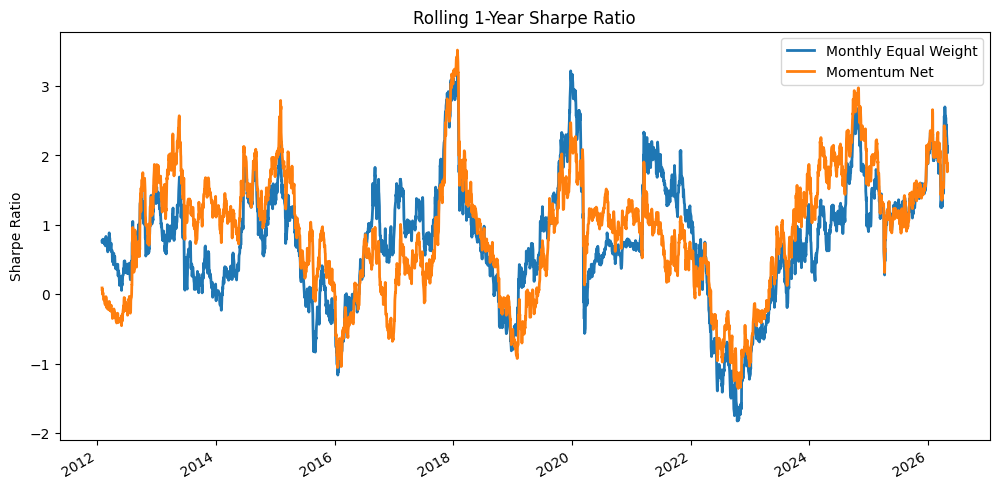

In [13]:
rolling_sharpe = pd.DataFrame({
    "Monthly Equal Weight":
        (
            monthly_equal_weight_returns.rolling(252).mean()
            /
            monthly_equal_weight_returns.rolling(252).std()
        ) * (252 ** 0.5),

    "Momentum Net":
        (
            cost_results["net_return"].rolling(252).mean()
            /
            cost_results["net_return"].rolling(252).std()
        ) * (252 ** 0.5),
})

rolling_sharpe.plot(
    figsize=(12, 6),
    linewidth=2,
    title="Rolling 1-Year Sharpe Ratio",
)

plt.ylabel("Sharpe Ratio")
plt.show()

### Interpretation

- Volatility increased significantly during major market stress periods.
- Momentum exhibited higher volatility than the benchmark during most periods, except of COVID-19, where it shows significantly lower rolling volatility.
- Rolling Sharpe ratios varied through time, indicating that strategy effectiveness was regime-dependent. Correlating strongly with volatility, as expected.
- Momentum generated its strongest risk-adjusted performance during the end of 2017 and the early start of 2018.

## 7. Portfolio Diagnostics

Understanding performance requires understanding portfolio behavior.

The following diagnostics analyze:
- ETF selection frequency
- turnover
- transaction costs
- portfolio changes during regime shifts

In [14]:
from src.diagnostics import momentum_selection_frequency

In [15]:
selection_counts = momentum_selection_frequency(
    signals=signals,
    n_assets=3,
)

selection_counts

SPY    3117
VNQ    2291
GLD    2032
EFA    1795
TLT    1267
EEM    1090
AGG       0
dtype: int64

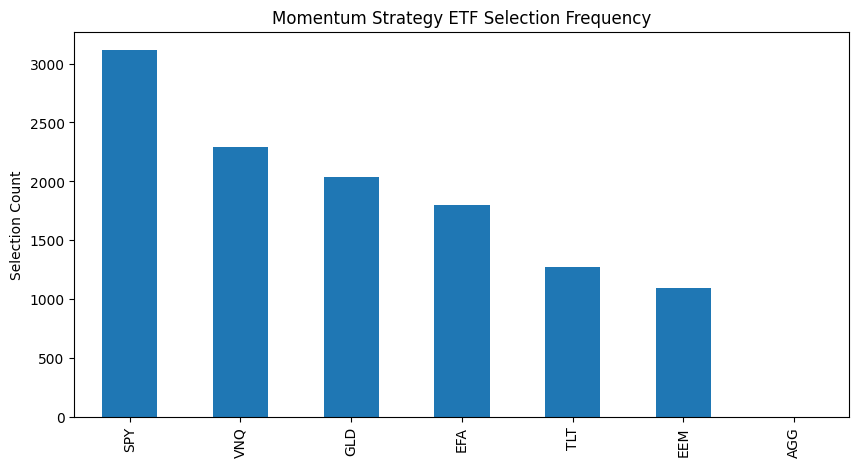

In [16]:
selection_counts.plot.bar(
    figsize=(10, 5),
    title="Momentum Strategy ETF Selection Frequency",
)

plt.ylabel("Selection Count")
plt.show()

### ETF Selection Frequency

SPY was selected most frequently, indicating that US equities were often among the strongest momentum assets.

VNQ and GLD were also selected often, suggesting that the strategy rotated across real estate and gold rather than only holding equities.

AGG was never selected because the data series contained no valid observations in this dataset.

In [17]:
turnover_series = cost_results.loc[
    cost_results["turnover"] > 0,
    "turnover"
]

turnover_series.describe()

count    129.000000
mean       0.147019
std        0.196764
min        0.001073
25%        0.007483
50%        0.015971
75%        0.335825
max        0.669096
Name: turnover, dtype: float64

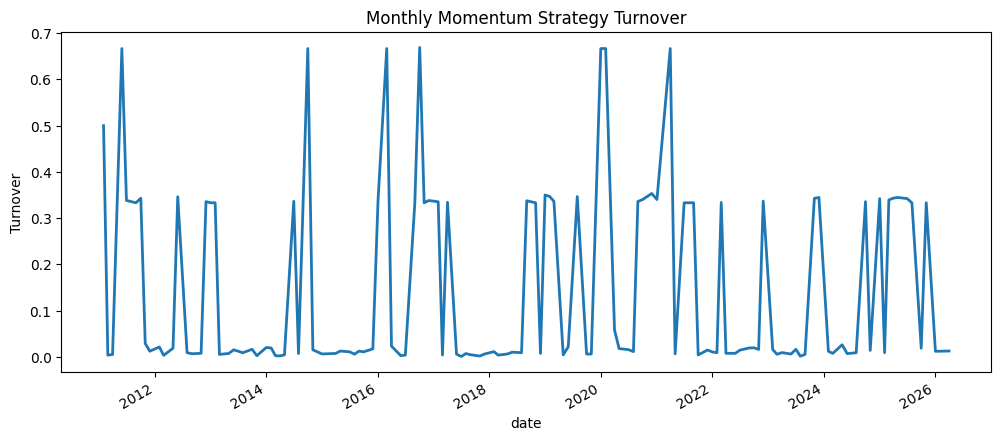

In [18]:
turnover_series.plot(
    figsize=(12, 5),
    linewidth=2,
    title="Monthly Momentum Strategy Turnover",
)

plt.ylabel("Turnover")
plt.show()

In [19]:
cost_summary = pd.Series({
    "Total Turnover": cost_results["turnover"].sum(),
    "Average Turnover per Rebalance": turnover_series.mean(),
    "Median Turnover per Rebalance": turnover_series.median(),
    "Total Cost Drag": cost_results["transaction_cost"].sum(),
    "Number of Rebalances": len(turnover_series),
})

cost_summary

Total Turnover                     18.965457
Average Turnover per Rebalance      0.147019
Median Turnover per Rebalance       0.015971
Total Cost Drag                     0.018965
Number of Rebalances              129.000000
dtype: float64

### Turnover and Transaction Costs

Turnover was generally low in most months, indicating that the momentum rankings were relatively persistent.

However, turnover spiked during regime changes when multiple ETFs entered or left the top-3 ranking.

At most, 2/3 of the assets were swapped.

The strategy's total transaction cost drag remained limited, suggesting that monthly rebalancing helped keep implementation costs manageable.

In [20]:
largest_turnover_date = turnover_series.idxmax()

largest_turnover_date

Timestamp('2016-10-03 00:00:00')

In [21]:
month_ends = returns.resample("ME").last().index
month_ends = month_ends.intersection(returns.index)

signal_date = month_ends[
    month_ends < largest_turnover_date
][-1]

previous_signal_date = month_ends[
    month_ends < signal_date
][-1]

signal_date, previous_signal_date

(Timestamp('2016-09-30 00:00:00'), Timestamp('2016-08-31 00:00:00'))

In [22]:
previous_top3 = signals.loc[
    previous_signal_date
].nlargest(3)

current_top3 = signals.loc[
    signal_date
].nlargest(3)

pd.DataFrame({
    "Previous Top 3": previous_top3,
    "Current Top 3": current_top3,
})

,Previous Top 3,Current Top 3
EEM,NaN,0.162999
GLD,NaN,0.177176
SPY,0.158123,NaN
TLT,0.171749,NaN
VNQ,0.280123,0.190301


### Turnover Case Study: October 2016

The largest turnover event occurred on 2016-10-03.

The previous momentum portfolio selected:
- VNQ
- TLT
- SPY

The new momentum portfolio selected:
- VNQ
- GLD
- EEM

VNQ remained in the portfolio, while TLT and SPY were replaced by GLD and EEM.

This replacement of two out of three holdings resulted in turnover of approximately 67%, illustrating that turnover spikes occur when momentum leadership changes across asset classes.

## 8. Limitations

This analysis has several limitations:

- The ETF universe is small and may not fully represent the investable opportunity set.
- The momentum signal is based solely on trailing returns and ignores valuation, macroeconomic, and fundamental information.
- Transaction costs are modeled using a simple fixed cost assumption and do not account for bid-ask spreads, market impact, or varying liquidity conditions.
- Taxes and financing costs are ignored.
- No optimization or risk targeting framework is applied.

## 9. Conclusions

This project evaluated a simple cross-sectional momentum strategy within a diversified ETF universe.

Key findings:

- The momentum strategy successfully identified changing market leadership across asset classes.
- Momentum performance exceeded the monthly equal-weight benchmark.
- Transaction costs reduced returns but remained manageable due to relatively low portfolio turnover, but are based on assumptions.
- Most rebalances resulted in small portfolio changes, while turnover spikes occurred primarily during regime shifts.
- The strategy rotated across equities, real estate, gold, and fixed income rather than maintaining constant exposure to a single asset class.

Overall, the results suggest that a simple momentum-based asset allocation framework can provide a systematic and implementable approach to portfolio construction.

## 10. Future Improvements

Potential future extensions include:

- Larger ETF or global asset universe
- Risk-adjusted momentum signals
- Volatility targeting
- Portfolio optimization techniques
- More realistic transaction cost models
- Factor attribution and performance decomposition